In [47]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [48]:
df = pd.read_csv("modeling_ready_dataset.csv")

key_cols = ["season", "team"]
target_col = "made_playoffs"
feature_cols = [c for c in df.columns if c not in key_cols + [target_col]]

Creating 5 expanding window folds for temporal validation. 

Each fold trains on all prior seasons and tests on the next unseen year, ensuring the model never sees future data during training. We want to assess performance stability across multiple seasons

In [49]:
folds = []
for test_year in range(2021, 2026):
    train_mask = df["season"] < test_year
    test_mask = df["season"] == test_year

    fold = {
        "fold_num": test_year - 2020,
        "test_year": test_year,
        "train_seasons": sorted(df[train_mask]["season"].unique()),
        "X_train": df.loc[train_mask, feature_cols],
        "y_train": df.loc[train_mask, target_col],
        "X_test": df.loc[test_mask, feature_cols],
        "y_test": df.loc[test_mask, target_col],
    }
    folds.append(fold)

In [50]:
print(f"{'Fold':<6s} {'Train Seasons':<10s} {'Train Rows':>10s} {'Train PO%':>10s} {'Test Year':>10s} {'Test Rows':>10s} {'Test PO%':>9s}")

for fold in folds:
    train_seasons_str = f"2018-{fold['train_seasons'][-1]}"
    train_po = fold["y_train"].mean() * 100
    test_po = fold["y_test"].mean() * 100
    print(f"{fold['fold_num']:<6d} {train_seasons_str:<10s} {len(fold['X_train']):>10d} {train_po:>9.1f}% {fold['test_year']:>10d} {len(fold['X_test']):>10d} {test_po:>8.1f}%")

Fold   Train Seasons Train Rows  Train PO%  Test Year  Test Rows  Test PO%
1      2018-2020          96      39.6%       2021         32     43.8%
2      2018-2021         128      40.6%       2022         32     43.8%
3      2018-2022         160      41.2%       2023         32     43.8%
4      2018-2023         192      41.7%       2024         32     43.8%
5      2018-2024         224      42.0%       2025         32     43.8%


Verifying that no data leakage exists by confirming each fold's test year comes strictly after its latest training season. If any test data overlapped with training data, the assertion would stop the script and flag the problem

In [51]:
# Verify no data leakage ---
print("Data leakage verification:")
for fold in folds:
    max_train = fold["train_seasons"][-1]
    assert fold["test_year"] > max_train, f"LEAKAGE in fold {fold['fold_num']}!"
    print(f"  Fold {fold['fold_num']}: Train through {max_train}, test on {fold['test_year']} — OK")

Data leakage verification:
  Fold 1: Train through 2020, test on 2021 — OK
  Fold 2: Train through 2021, test on 2022 — OK
  Fold 3: Train through 2022, test on 2023 — OK
  Fold 4: Train through 2023, test on 2024 — OK
  Fold 5: Train through 2024, test on 2025 — OK


### Baseline Benchmarks

Before building any real models, we establish baseline benchmarks to measure against. The evaluate_model helper function computes accuracy, precision, recall, F1, and AUC-ROC so we can reuse it consistently across all models. After creating the helper function, the first baseline always predicts non-playoff (0) for every team, representing the simplest possible approach. Any useful model must outperform this floor. Results are stored in all_results so we can compare all models side by side later.

In [52]:
# Helper function to compute all metrics
def evaluate_model(y_true, y_pred, y_prob=None):
    """Compute standard classification metrics."""
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob)
    return metrics

In [53]:
# Storage for all results
all_results = []

# --- Baseline 1: Naive Majority Class ---
print("\n--- Baseline 1: Naive Majority Class (always predict 0) ---")
print(f"  {'Fold':<6s} {'Test Year':>9s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s}")
print(f"  {'-'*40}")

for fold in folds:
    y_pred = np.zeros(len(fold["y_test"]), dtype=int)
    metrics = evaluate_model(fold["y_test"], y_pred)
    metrics["auc_roc"] = 0.5

    print(f"  {fold['fold_num']:<6d} {fold['test_year']:>9d} {metrics['accuracy']:>7.3f} {metrics['precision']:>7.3f} {metrics['recall']:>7.3f} {metrics['f1']:>7.3f}")

    all_results.append({
        "model": "Naive Majority",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })


--- Baseline 1: Naive Majority Class (always predict 0) ---
  Fold   Test Year     Acc    Prec  Recall      F1
  ----------------------------------------
  1           2021   0.562   0.000   0.000   0.000
  2           2022   0.562   0.000   0.000   0.000
  3           2023   0.562   0.000   0.000   0.000
  4           2024   0.562   0.000   0.000   0.000
  5           2025   0.562   0.000   0.000   0.000


Observing the output we see it predicts 56.2% accuracy just by saying no one will make the playoffs. Precision, recall, and F1 are all 0 because the model never predicts a single team as a playoff team. We gather that accuracy alone can be misleading because 56% sounds decent, but its useless when it cant identify a single playoff team. This baseline sets the absolute floor, so any model must beat the accuracy and also actually identify playoff teams.

**Second Baseline**

Our second baseline tests how far a single feature can go without any machine learning. Using score_pct_diff, which was our strongest predictor at r=0.704, we find the optimal threshold on training data that maximizes F1, then apply it to the test set.  If a team's scoring efficiency differential is above the threshold we want to predict playoff, otherwise, we predict non-playoffs.

In [55]:
print(f"  {'Fold':<6s} {'Test Year':>9s} {'Threshold':>10s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s} {'AUC':>7s}")
print(f"  {'-'*60}")
best_feature = "score_pct_diff"

for fold in folds:
    train_vals = fold["X_train"][best_feature]
    train_labels = fold["y_train"]

    best_threshold = 0
    best_f1 = 0

    for threshold in np.arange(train_vals.min(), train_vals.max(), 0.5):
        preds = (train_vals >= threshold).astype(int)
        f1 = f1_score(train_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    y_pred = (fold["X_test"][best_feature] >= best_threshold).astype(int)

    train_min = train_vals.min()
    train_max = train_vals.max()
    y_prob = (fold["X_test"][best_feature] - train_min) / (train_max - train_min)
    y_prob = y_prob.clip(0, 1)

    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    print(f"  {fold['fold_num']:<6d} {fold['test_year']:>9d} {best_threshold:>10.1f} {metrics['accuracy']:>7.3f} {metrics['precision']:>7.3f} {metrics['recall']:>7.3f} {metrics['f1']:>7.3f} {metrics['auc_roc']:>7.3f}")

    all_results.append({
        "model": "Heuristic (score_pct_diff)",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })
 

  Fold   Test Year  Threshold     Acc    Prec  Recall      F1     AUC
  ------------------------------------------------------------
  1           2021       -1.2   0.750   0.650   0.929   0.765   0.929
  2           2022       -0.5   0.781   0.733   0.786   0.759   0.881
  3           2023       -1.0   0.875   0.812   0.929   0.867   0.909
  4           2024       -1.0   0.844   0.765   0.929   0.839   0.972
  5           2025       -1.0   0.750   0.667   0.857   0.750   0.875


In [68]:
# Producing the averages 
heuristic = results_df[results_df["model"] == "Heuristic (score_pct_diff)"]
for metric in ["accuracy", "precision", "recall", "f1", "auc_roc"]:
    print(round(heuristic[metric].mean(), 3))

0.8
0.725
0.886
0.796
0.913


Observing this output we can takeaway that a single feature with a simple threshold achieves 80% accuracy and .796 average F1 across all folds. A high recall average of 88.6% means it catches most playoff teams. While the precison score of 72.5% means it also flags non-playoff teams incorrectly. 

So, with our upcoming models of Logistic Regression, Random Forest and Gradient Boosting we need to beat the 0.796 F1 to justify their use over this simple one feature rule.

### Logistic Regression

We want to determine of the 64 features we still have if we should eliminate the weak features, or keep them all and how aggressively to regularize the data. Using the 2 penalties L1(Lasso), and L2(Ridge) will help determine feature results, while C will control how much regularization is applied.

In [71]:
param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "penalty": ["l1", "l2"],
}


In [ ]:
lr_models = []

for fold in folds:
    # Scale features: fit on training data ONLY to prevent leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(fold["X_train"])
    X_test_scaled = scaler.transform(fold["X_test"])

    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lr = LogisticRegression(solver="saga", max_iter=5000, random_state=42)

    # Find the best C and penalty combination out of our 10 options from param_grid_lr
    grid_search = GridSearchCV(
        estimator=lr,
        param_grid=param_grid_lr,
        cv=cv_inner,
        scoring="f1",
        n_jobs=-1,
        refit=True,
    )

    grid_search.fit(X_train_scaled, fold["y_train"])
    
    best_lr = grid_search.best_estimator_
    best_params = grid_search.best_params_

    y_pred = best_lr.predict(X_test_scaled)
    y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)

    print(f"  {fold['fold_num']:<6d} {fold['test_year']:>9d} {best_params['C']:>7.3f} {best_params['penalty']:>5s} "
          f"{metrics['accuracy']:>7.3f} {metrics['precision']:>7.3f} {metrics['recall']:>7.3f} {metrics['f1']:>7.3f} {metrics['auc_roc']:>7.3f}")

    all_results.append({
        "model": "Logistic Regression",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })

    lr_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_lr,
        "scaler": scaler,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })

  1           2021   1.000    l1   0.812   0.750   0.857   0.800   0.905
  2           2022   0.100    l2   0.812   1.000   0.571   0.727   0.968
  3           2023  10.000    l1   0.969   1.000   0.929   0.963   0.992
  4           2024  10.000    l1   1.000   1.000   1.000   1.000   1.000
  5           2025  10.000    l1   0.938   0.929   0.929   0.929   0.984


Observing this output we can notice already how much the accuracy is improved and the F1 values increased as well. L1 penalty was selected in 4 out of 5 folds, which confirms that feature elimination helps with this dataset. The C value increases as more training data becomes available, from 1.0 in Fold 1 to 10.0 in Folds 3 through 5, meaning the model uses less regularization when it has more data to learn from, which makes sense. Fold 4 in 2022, achieved perfect scores, while fild 2 in 2022 had the weakest. 

Most importantly we can takeaway that this beat both baselines. 

Now, to see which features matter most and whether they push toward or against playoff qualification.

In [ ]:
# extracting the fold 5 models coefficients trained on the most data to see which features matter most
# and whether they push toward or against playoff qualification.
final_lr = lr_models[-1]["model"]
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": final_lr.coef_[0],
    "abs_coef": np.abs(final_lr.coef_[0])
}).sort_values("abs_coef", ascending=False)

for _, row in coef_df.head(15).iterrows():
    print(f"{row['feature']:<20s} {row['coefficient']:>+12.4f}")

# The non-zero coef count shows how many featyres L1 reg kept vs eliminated, tells us how much model simplified itself
n_nonzero = (coef_df["abs_coef"] > 0.001).sum()
n_zero = len(coef_df) - n_nonzero
print(round(n_nonzero/len(feature_cols),3))
print(n_zero)
 
# Best parameters per fold
for m in lr_models:
    print(f"Fold{m['fold']}({m['test_year']}):C={m['best_params']['C']},penalty={m['best_params']['penalty']},CV F1={m['cv_best_score']:.3f}")

def_adv_Air               +8.8036
def_adv_YAC               +5.6444
def_yds_allowed           -5.0437
def_yds_per_play          -4.4453
def_rush_Yds              +2.8858
def_plays                 -2.7133
def_pass_ANY/A            -2.4101
def_rush_Y/A              +2.0597
def_rush_Att              +1.2705
off_score_pct             +1.1693
def_pass_Sk               -1.1522
score_pct_diff            +0.9683
def_pass_Rate             -0.9370
off_pass_Cmp%             +0.8471
def_pass_Int              -0.7291
0.631
24
Fold1(2021):C=1.0,penalty=l1,CV F1=0.921
Fold2(2022):C=0.1,penalty=l2,CV F1=0.871
Fold3(2023):C=10.0,penalty=l1,CV F1=0.894
Fold4(2024):C=10.0,penalty=l1,CV F1=0.943
Fold5(2025):C=10.0,penalty=l1,CV F1=0.958


**Random Forest**

In [ ]:
print(f"\n{'=' * 70}")
print("BLOCK 4: RANDOM FOREST")
print("=" * 70)
 
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [5, 10],
}
 
total_combos = len(param_grid_rf["n_estimators"]) * len(param_grid_rf["max_depth"]) * len(param_grid_rf["min_samples_split"])
print("\nHyperparameter grid:")
print(f"  n_estimators: {param_grid_rf['n_estimators']}")
print(f"  max_depth: {param_grid_rf['max_depth']}")
print(f"  min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"  Total combinations: {total_combos}")
print()
 
# Random Forest does NOT require feature scaling
print(f"  {'Fold':<6s} {'Test Year':>9s} {'Trees':>6s} {'Depth':>6s} {'MinSS':>6s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s} {'AUC':>7s}")
print(f"  {'-'*72}")
 
rf_models = []
 
for fold in folds:
    X_train = fold["X_train"]
    X_test = fold["X_test"]
 
    # 3-fold CV for computational efficiency with RF
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid_rf,
        cv=cv_inner,
        scoring="f1",
        n_jobs=1,
        refit=True,
    )
 
    grid_search.fit(X_train, fold["y_train"])
 
    best_rf = grid_search.best_estimator_
    best_params = grid_search.best_params_
 
    y_pred = best_rf.predict(X_test)
    y_prob = best_rf.predict_proba(X_test)[:, 1]
 
    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)
 
    depth_str = str(best_params["max_depth"]) if best_params["max_depth"] is not None else "None"
    print(f"  {fold['fold_num']:<6d} {fold['test_year']:>9d} {best_params['n_estimators']:>6d} {depth_str:>6s} "
          f"{best_params['min_samples_split']:>6d} {metrics['accuracy']:>7.3f} {metrics['precision']:>7.3f} "
          f"{metrics['recall']:>7.3f} {metrics['f1']:>7.3f} {metrics['auc_roc']:>7.3f}")
 
    all_results.append({
        "model": "Random Forest",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })
 
    rf_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_rf,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })


BLOCK 4: RANDOM FOREST

Hyperparameter grid:
  n_estimators: [100, 200]
  max_depth: [5, 10, None]
  min_samples_split: [5, 10]
  Total combinations: 12

  Fold   Test Year  Trees  Depth  MinSS     Acc    Prec  Recall      F1     AUC
  ------------------------------------------------------------------------
  1           2021    200      5      5   0.750   0.750   0.643   0.692   0.865
  2           2022    200     10      5   0.750   0.875   0.500   0.636   0.952
  3           2023    100      5      5   0.781   0.889   0.571   0.696   0.952
  4           2024    100      5     10   0.906   0.923   0.857   0.889   0.944
  5           2025    100     10     10   0.844   0.800   0.857   0.828   0.909


In [ ]:
# Summary
print("\n--- Random Forest Summary (averages across 5 folds) ---")
rf_results = pd.DataFrame(all_results)
rf_results = rf_results[rf_results["model"] == "Random Forest"]
 
for metric in ["accuracy", "precision", "recall", "f1", "auc_roc"]:
    avg = rf_results[metric].mean()
    std = rf_results[metric].std()
    print(f"  {metric:<12s}  {avg:.3f} (+/- {std:.3f})")



--- Random Forest Summary (averages across 5 folds) ---
  accuracy      0.806 (+/- 0.068)
  precision     0.847 (+/- 0.071)
  recall        0.686 (+/- 0.164)
  f1            0.748 (+/- 0.105)
  auc_roc       0.925 (+/- 0.038)


In [ ]:
# Feature importance (Fold 5)
print("\n--- Top 15 Features by Importance (Fold 5) ---")
final_rf = rf_models[-1]["model"]
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_rf.feature_importances_,
}).sort_values("importance", ascending=False)
 
print(f"  {'Feature':<30s} {'Importance':>12s} {'Cumulative %':>13s}")
print(f"  {'-'*57}")
cumulative = 0
for _, row in importance_df.head(15).iterrows():
    cumulative += row["importance"]
    print(f"  {row['feature']:<30s} {row['importance']:>12.4f} {cumulative*100:>12.1f}%")
 
print(f"\n  Top 15 features account for {cumulative*100:.1f}% of total importance")
print(f"  Remaining {len(feature_cols) - 15} features account for {(1-cumulative)*100:.1f}%")


--- Top 15 Features by Importance (Fold 5) ---
  Feature                          Importance  Cumulative %
  ---------------------------------------------------------
  score_pct_diff                       0.1418         14.2%
  pass_eff_diff                        0.0970         23.9%
  off_score_pct                        0.0621         30.1%
  off_pts                              0.0555         35.6%
  def_pa                               0.0418         39.8%
  off_pass_Rate                        0.0404         43.9%
  turnover_margin                      0.0313         47.0%
  to_rate_diff                         0.0307         50.1%
  def_pass_QBHits                      0.0252         52.6%
  off_yds                              0.0239         55.0%
  off_pass_ANY/A                       0.0227         57.3%
  def_score_pct                        0.0210         59.4%
  ypp_diff                             0.0182         61.2%
  def_adv_Air                          0.0178       

In [ ]:
# Best parameters per fold
print("\n--- Best Parameters Per Fold ---")
for m in rf_models:
    depth_str = str(m["best_params"]["max_depth"]) if m["best_params"]["max_depth"] is not None else "None"
    print(f"  Fold {m['fold']} ({m['test_year']}): n_estimators={m['best_params']['n_estimators']}, "
          f"max_depth={depth_str}, min_samples_split={m['best_params']['min_samples_split']}, "
          f"CV F1={m['cv_best_score']:.3f}")
 
print("\nBlock 4 complete. Random Forest evaluated.")
 


--- Best Parameters Per Fold ---
  Fold 1 (2021): n_estimators=200, max_depth=5, min_samples_split=5, CV F1=0.878
  Fold 2 (2022): n_estimators=200, max_depth=10, min_samples_split=5, CV F1=0.799
  Fold 3 (2023): n_estimators=100, max_depth=5, min_samples_split=5, CV F1=0.807
  Fold 4 (2024): n_estimators=100, max_depth=5, min_samples_split=10, CV F1=0.809
  Fold 5 (2025): n_estimators=100, max_depth=10, min_samples_split=10, CV F1=0.815

Block 4 complete. Random Forest evaluated.


In [ ]:
print(f"\n{'=' * 70}")
print("BLOCK 5: GRADIENT BOOSTING")
print("=" * 70)
 
param_grid_gb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
}
 
total_combos = len(param_grid_gb["n_estimators"]) * len(param_grid_gb["max_depth"]) * len(param_grid_gb["learning_rate"]) * len(param_grid_gb["subsample"])
print("\nHyperparameter grid:")
print(f"  n_estimators: {param_grid_gb['n_estimators']}")
print(f"  max_depth: {param_grid_gb['max_depth']}")
print(f"  learning_rate: {param_grid_gb['learning_rate']}")
print(f"  subsample: {param_grid_gb['subsample']}")
print(f"  Total combinations: {total_combos}")
print()
 
# Gradient Boosting does NOT require feature scaling
print(f"  {'Fold':<6s} {'Test Year':>9s} {'LR':>6s} {'Depth':>6s} {'Trees':>6s} {'Sub':>5s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s} {'AUC':>7s}")
print(f"  {'-'*78}")
 
gb_models = []
 
for fold in folds:
    X_train = fold["X_train"]
    X_test = fold["X_test"]
 
    # 3-fold CV for computational efficiency
    cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 
    grid_search = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grid_gb,
        cv=cv_inner,
        scoring="f1",
        n_jobs=-1,
        refit=True,
    )
 
    grid_search.fit(X_train, fold["y_train"])
 
    best_gb = grid_search.best_estimator_
    best_params = grid_search.best_params_
 
    y_pred = best_gb.predict(X_test)
    y_prob = best_gb.predict_proba(X_test)[:, 1]
 
    metrics = evaluate_model(fold["y_test"], y_pred, y_prob)
 
    print(f"  {fold['fold_num']:<6d} {fold['test_year']:>9d} {best_params['learning_rate']:>6.2f} {best_params['max_depth']:>6d} "
          f"{best_params['n_estimators']:>6d} {best_params['subsample']:>5.1f} {metrics['accuracy']:>7.3f} {metrics['precision']:>7.3f} "
          f"{metrics['recall']:>7.3f} {metrics['f1']:>7.3f} {metrics['auc_roc']:>7.3f}")
 
    all_results.append({
        "model": "Gradient Boosting",
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        **metrics
    })
 
    gb_models.append({
        "fold": fold["fold_num"],
        "test_year": fold["test_year"],
        "model": best_gb,
        "best_params": best_params,
        "cv_best_score": grid_search.best_score_,
    })
 
# Summary
print("\n--- Gradient Boosting Summary (averages across 5 folds) ---")
gb_results = pd.DataFrame(all_results)
gb_results = gb_results[gb_results["model"] == "Gradient Boosting"]
 
for metric in ["accuracy", "precision", "recall", "f1", "auc_roc"]:
    avg = gb_results[metric].mean()
    std = gb_results[metric].std()
    print(f"  {metric:<12s}  {avg:.3f} (+/- {std:.3f})")
 


BLOCK 5: GRADIENT BOOSTING

Hyperparameter grid:
  n_estimators: [100, 200]
  max_depth: [3, 5]
  learning_rate: [0.01, 0.1]
  subsample: [0.8, 1.0]
  Total combinations: 16

  Fold   Test Year     LR  Depth  Trees   Sub     Acc    Prec  Recall      F1     AUC
  ------------------------------------------------------------------------------
  1           2021   0.10      5    100   0.8   0.750   0.714   0.714   0.714   0.841
  2           2022   0.10      5    100   1.0   0.781   0.889   0.571   0.696   0.909
  3           2023   0.10      3    200   0.8   0.875   0.812   0.929   0.867   0.921
  4           2024   0.10      3    200   0.8   0.906   0.923   0.857   0.889   0.980
  5           2025   0.01      3    200   0.8   0.812   0.786   0.786   0.786   0.873

--- Gradient Boosting Summary (averages across 5 folds) ---
  accuracy      0.825 (+/- 0.065)
  precision     0.825 (+/- 0.083)
  recall        0.771 (+/- 0.137)
  f1            0.790 (+/- 0.087)
  auc_roc       0.905 (+/- 0.0

In [ ]:
# Feature importance (Fold 5)
print("\n--- Top 15 Features by Importance (Fold 5) ---")
final_gb = gb_models[-1]["model"]
importance_df_gb = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_gb.feature_importances_,
}).sort_values("importance", ascending=False)
 
print(f"  {'Feature':<30s} {'Importance':>12s} {'Cumulative %':>13s}")
print(f"  {'-'*57}")
cumulative = 0
for _, row in importance_df_gb.head(15).iterrows():
    cumulative += row["importance"]
    print(f"  {row['feature']:<30s} {row['importance']:>12.4f} {cumulative*100:>12.1f}%")
 
print(f"\n  Top 15 features account for {cumulative*100:.1f}% of total importance")
print(f"  Remaining {len(feature_cols) - 15} features account for {(1-cumulative)*100:.1f}%")
 
# Best parameters per fold
print("\n--- Best Parameters Per Fold ---")
for m in gb_models:
    print(f"  Fold {m['fold']} ({m['test_year']}): lr={m['best_params']['learning_rate']}, "
          f"max_depth={m['best_params']['max_depth']}, n_estimators={m['best_params']['n_estimators']}, "
          f"subsample={m['best_params']['subsample']}, CV F1={m['cv_best_score']:.3f}")
 
print("\nBlock 5 complete. Gradient Boosting evaluated.")
 


--- Top 15 Features by Importance (Fold 5) ---
  Feature                          Importance  Cumulative %
  ---------------------------------------------------------
  score_pct_diff                       0.5344         53.4%
  def_adv_Air                          0.0741         60.8%
  pass_eff_diff                        0.0583         66.7%
  def_adv_YAC                          0.0256         69.2%
  off_turnover_pct                     0.0228         71.5%
  def_pass_Sk                          0.0159         73.1%
  off_rush_TD                          0.0154         74.6%
  def_pass_Rate                        0.0151         76.1%
  ypp_diff                             0.0149         77.6%
  off_plays                            0.0142         79.1%
  def_pa                               0.0140         80.5%
  def_pass_ANY/A                       0.0113         81.6%
  off_score_pct                        0.0110         82.7%
  def_yds_allowed                      0.0109       

In [ ]:
# BLOCK 6: CROSS-MODEL COMPARISON SUMMARY
# ──────────────────────────────────────────────────────────────────────────────
 
print(f"\n{'=' * 70}")
print("BLOCK 6: CROSS-MODEL COMPARISON SUMMARY")
print("=" * 70)
 
final_results = pd.DataFrame(all_results)
 
print("\n--- Average Performance Across 5 Expanding Window Folds ---")
print(f"  {'Model':<30s} {'Acc':>7s} {'Prec':>7s} {'Recall':>7s} {'F1':>7s} {'AUC':>7s}")
print(f"  {'-'*65}")
 
for model_name in ["Naive Majority", "Heuristic (score_pct_diff)", "Logistic Regression", "Random Forest", "Gradient Boosting"]:
    model_data = final_results[final_results["model"] == model_name]
    acc = model_data["accuracy"].mean()
    prec = model_data["precision"].mean()
    rec = model_data["recall"].mean()
    f1 = model_data["f1"].mean()
    auc = model_data["auc_roc"].mean()
    print(f"  {model_name:<30s} {acc:>7.3f} {prec:>7.3f} {rec:>7.3f} {f1:>7.3f} {auc:>7.3f}")
 
# Per-fold F1 comparison
print("\n--- F1 Score by Fold (Stability Comparison) ---")
print(f"  {'Model':<30s} {'2021':>7s} {'2022':>7s} {'2023':>7s} {'2024':>7s} {'2025':>7s} {'Avg':>7s} {'Std':>7s}")
print(f"  {'-'*85}")
 
for model_name in ["Heuristic (score_pct_diff)", "Logistic Regression", "Random Forest", "Gradient Boosting"]:
    model_data = final_results[final_results["model"] == model_name].sort_values("test_year")
    f1_scores = model_data["f1"].values
    avg = f1_scores.mean()
    std = f1_scores.std()
    scores_str = "".join([f" {s:>7.3f}" for s in f1_scores])
    print(f"  {model_name:<30s}{scores_str} {avg:>7.3f} {std:>7.3f}")
 
# Improvement over baselines
print("\n--- Improvement Over Baselines (F1 Score) ---")
naive_f1 = final_results[final_results["model"] == "Naive Majority"]["f1"].mean()
heuristic_f1 = final_results[final_results["model"] == "Heuristic (score_pct_diff)"]["f1"].mean()
 
for model_name in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
    model_f1 = final_results[final_results["model"] == model_name]["f1"].mean()
    vs_naive = model_f1 - naive_f1
    vs_heuristic = model_f1 - heuristic_f1
    print(f"  {model_name:<30s} vs Naive: +{vs_naive:.3f}   vs Heuristic: {vs_heuristic:+.3f}")
 
print("\nBlock 6 complete. All models compared.")
print("\n" + "=" * 70)
print("MODELING PIPELINE COMPLETE")
print("=" * 70)


BLOCK 6: CROSS-MODEL COMPARISON SUMMARY

--- Average Performance Across 5 Expanding Window Folds ---
  Model                              Acc    Prec  Recall      F1     AUC
  -----------------------------------------------------------------
  Naive Majority                   0.562   0.000   0.000   0.000   0.500
  Heuristic (score_pct_diff)       0.800   0.725   0.886   0.796   0.913
  Logistic Regression              0.906   0.936   0.857   0.884   0.970
  Random Forest                    0.806   0.847   0.686   0.748   0.925
  Gradient Boosting                0.825   0.825   0.771   0.790   0.905

--- F1 Score by Fold (Stability Comparison) ---
  Model                             2021    2022    2023    2024    2025     Avg     Std
  -------------------------------------------------------------------------------------
  Heuristic (score_pct_diff)       0.765   0.759   0.867   0.839   0.750   0.796   0.048
  Logistic Regression              0.800   0.727   0.963   1.000   0.929   0.

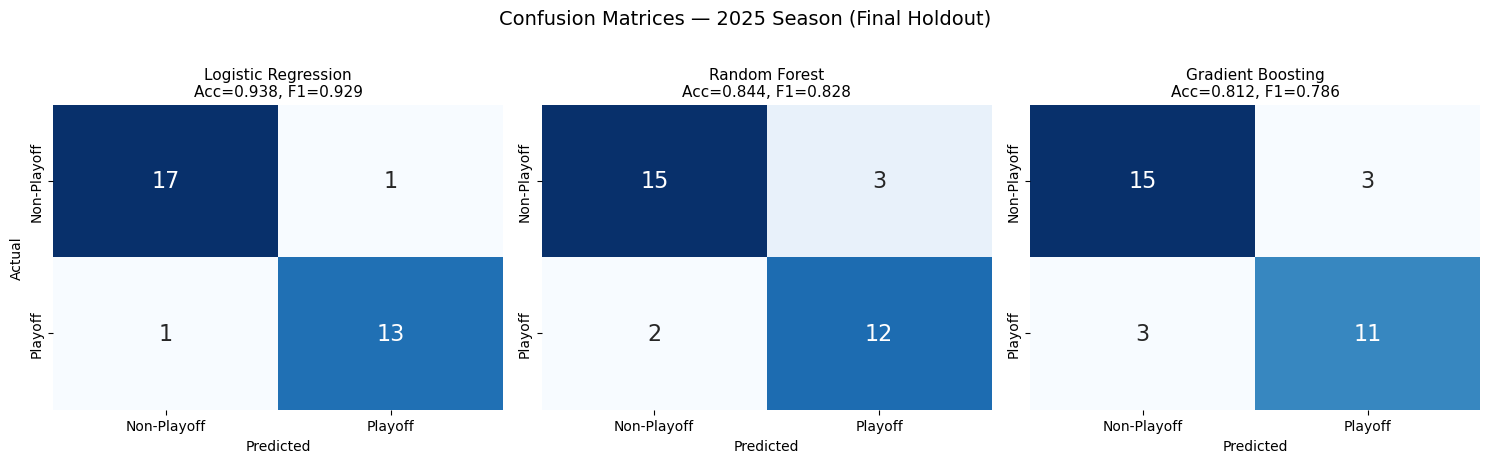

Saved: plot_confusion_matrices.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

df = pd.read_csv("modeling_ready_dataset.csv")
key_cols = ["season", "team"]
target_col = "made_playoffs"
feature_cols = [c for c in df.columns if c not in key_cols + [target_col]]

# ── Train all 3 models on Fold 5 (2018-2024 train, 2025 test) ──

X_train = df.loc[df["season"] < 2025, feature_cols]
y_train = df.loc[df["season"] < 2025, target_col]
X_test = df.loc[df["season"] == 2025, feature_cols]
y_test = df.loc[df["season"] == 2025, target_col]

# Logistic Regression (scaled)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
lr = LogisticRegression(C=10.0, penalty="l1", solver="saga", max_iter=5000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

# Random Forest (unscaled)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Gradient Boosting (unscaled)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.01, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# ═══════════════════════════════════════════════════════════════
# PLOT 1: CONFUSION MATRICES (all 3 models, Fold 5 / 2025 test)
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, name, preds in zip(axes, 
    ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    [lr_pred, rf_pred, gb_pred]):
    
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Playoff", "Playoff"],
                yticklabels=["Non-Playoff", "Playoff"],
                cbar=False, annot_kws={"size": 16})
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    ax.set_title(f"{name}\nAcc={acc:.3f}, F1={f1:.3f}", fontsize=11)
    ax.set_ylabel("Actual" if ax == axes[0] else "")
    ax.set_xlabel("Predicted")

fig.suptitle("Confusion Matrices — 2025 Season (Final Holdout)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plot_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_confusion_matrices.png")


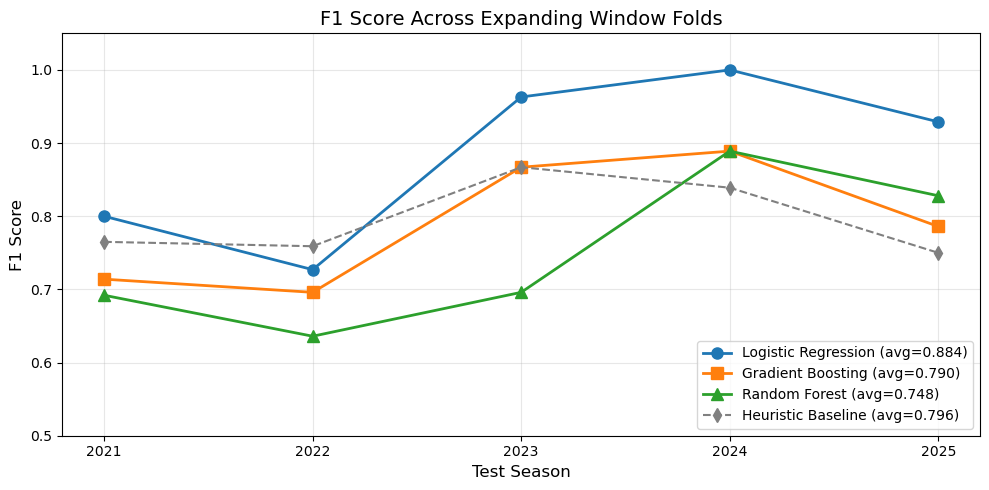

Saved: plot_f1_across_folds.png


In [ ]:
# PLOT 2: F1 SCORE ACROSS FOLDS (stability comparison)
# ═══════════════════════════════════════════════════════════════

# Hardcode results from our earlier runs
fold_years = [2021, 2022, 2023, 2024, 2025]

f1_lr = [0.800, 0.727, 0.963, 1.000, 0.929]
f1_rf = [0.692, 0.636, 0.696, 0.889, 0.828]
f1_gb = [0.714, 0.696, 0.867, 0.889, 0.786]
f1_heuristic = [0.765, 0.759, 0.867, 0.839, 0.750]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fold_years, f1_lr, "o-", label=f"Logistic Regression (avg={np.mean(f1_lr):.3f})", linewidth=2, markersize=8)
ax.plot(fold_years, f1_gb, "s-", label=f"Gradient Boosting (avg={np.mean(f1_gb):.3f})", linewidth=2, markersize=8)
ax.plot(fold_years, f1_rf, "^-", label=f"Random Forest (avg={np.mean(f1_rf):.3f})", linewidth=2, markersize=8)
ax.plot(fold_years, f1_heuristic, "d--", label=f"Heuristic Baseline (avg={np.mean(f1_heuristic):.3f})", linewidth=1.5, markersize=7, color="gray")

ax.set_xlabel("Test Season", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("F1 Score Across Expanding Window Folds", fontsize=14)
ax.set_xticks(fold_years)
ax.set_ylim(0.5, 1.05)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_f1_across_folds.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_f1_across_folds.png")

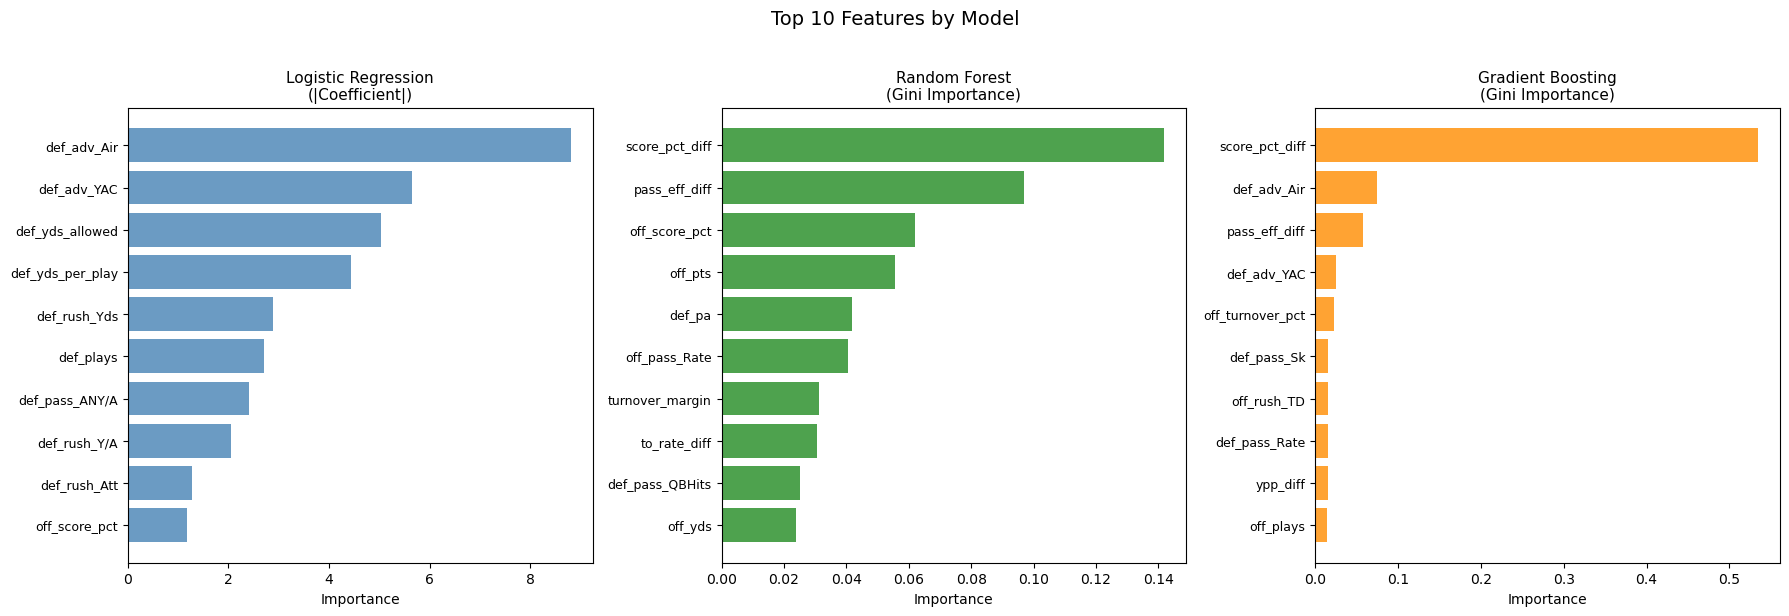

Saved: plot_feature_importance.png


In [ ]:
# PLOT 3: FEATURE IMPORTANCE COMPARISON (top 10 per model)
# ═══════════════════════════════════════════════════════════════

# LR: absolute coefficients
lr_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": np.abs(lr.coef_[0])
}).sort_values("importance", ascending=False).head(10)

# RF: built-in importance
rf_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

# GB: built-in importance
gb_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": gb.feature_importances_
}).sort_values("importance", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_df, name, color in zip(axes,
    [lr_imp, rf_imp, gb_imp],
    ["Logistic Regression\n(|Coefficient|)", "Random Forest\n(Gini Importance)", "Gradient Boosting\n(Gini Importance)"],
    ["steelblue", "forestgreen", "darkorange"]):
    
    ax.barh(range(len(imp_df)), imp_df["importance"].values, color=color, alpha=0.8)
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(imp_df["feature"].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Importance", fontsize=10)

fig.suptitle("Top 10 Features by Model", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_feature_importance.png")